# <span style="color:blue">Computer Vision - Spring 2026</span>

**Submission date:** Not for submission (Warm-up exercise)

---

## Welcome to Computer Vision!

This warm-up exercise will help you get familiar with:
- Jupyter notebooks and Python basics
- NumPy arrays and operations
- Matplotlib for visualization
- Basic image processing with OpenCV

**Instructions:**
- Read through all the examples carefully
- Run each code cell to see the output
- Complete the exercises marked as "YOUR TASK"
- If you have questions, please post on Piazza

---

## Table of Contents
1. [Setup and Imports](#setup)
2. [Python Basics](#python-basics)
3. [NumPy Arrays](#numpy-arrays)
4. [Plotting with Matplotlib](#plotting)
5. [Image Processing Basics](#images)
6. [Your Exercises](#exercises)

---
## 1. Setup and Imports <a id='setup'></a>

First, let's install the required packages and import the libraries we'll need throughout this course.

‼️ <span style="color:red"> It is highly recommended to run Jupyter Notebook via a virtual environment (venv) to avoid package version conflicts and to isolate project dependencies. Google / LLMs can help you set this up. Make sure you do it before running the package installation in the next cell. </span>

In [1]:
# Install required packages (run this cell once)
!pip install opencv-python numpy matplotlib scipy

In [2]:
# Import all necessary libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Configure matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = (6.0, 4.0)  # Set default figure size
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")

All libraries imported successfully!
NumPy version: 2.3.3
OpenCV version: 4.13.0


---
## 2. Python Basics <a id='python-basics'></a>

Let's review some basic Python concepts you'll use frequently.

### 2.1 Conditional Statements

Python uses `if-else` statements for conditional logic.

In [3]:
# Standard if-else statement
x = 6

if x > 4:
    print('Big')
else:
    print(x)

Big


In [4]:
# Compact ternary operator
print('Big') if x > 4 else print(x)

Big


---
## 3. NumPy Arrays <a id='numpy-arrays'></a>

NumPy is the fundamental package for scientific computing in Python. Arrays are the core data structure.

### 3.1 Creating Arrays

There are several ways to create NumPy arrays:

In [5]:
# Create a NumPy array from a python list
A = np.array([[1, 2, 3, 4, 5],
              [6, 7, 8, 9, 10]])

# Create array of zeros
M_zeros = np.zeros((7, 5), dtype=np.uint8)

# Create array of ones
M_ones = np.ones((7, 5), dtype=np.float32)

print('Array A:')
print(A)
print('\nArray of zeros (7x5):')
print(M_zeros)
print('\nArray of ones (7x5):')
print(M_ones)

# There are many other methods that create NumPy arrays.
# For example: np.full, np.linspace, np.eye, np.diag, np.random.rand, ...

Array A:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]

Array of zeros (7x5):
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

Array of ones (7x5):
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


### 3.2 Array Properties

Every array has important properties like shape and data type.

In [6]:
print(f'Shape of A: {A.shape}')  # Returns (rows, columns) when A is 2D
print(f'Alternative way: {np.shape(A)}')
print(f'Data type of A: {A.dtype}')
print(f'Number of dimensions: {A.ndim}')
print(f'Total number of elements: {A.size}')

Shape of A: (2, 5)
Alternative way: (2, 5)
Data type of A: int64
Number of dimensions: 2
Total number of elements: 10


### 3.3 Array Indexing and Slicing

**Important:** Python uses 0-based indexing!

In [7]:
print('Original array A:')
print(A)

Original array A:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]


In [8]:
print(f'Element at row 0, column 1: {A[0, 1]}')

Element at row 0, column 1: 2


In [9]:
print(f'Last element of first row: {A[0, -1]}')

Last element of first row: 5


In [10]:
print(f'Second row, from column 2 onwards: {A[1, 2:]}')

Second row, from column 2 onwards: [ 8  9 10]


In [11]:
print(f'First column: {A[:, 0]}')

First column: [1 6]


In [12]:
print(f'First column, keeping the column shape:\n{A[:, 0:1]}')

First column, keeping the column shape:
[[1]
 [6]]


In [13]:
print(f'All rows, columns 1-3:\n{A[:, 1:4]}')

All rows, columns 1-3:
[[2 3 4]
 [7 8 9]]


In [14]:
print(f'All rows, columns 1-3, in jumps (stride) of 2:\n{A[:, 1:4:2]}')

All rows, columns 1-3, in jumps (stride) of 2:
[[2 4]
 [7 9]]


In [15]:
print(f'All rows, columns 0, 1, and 4:\n{A[:, [0, 1, 4]]}')

All rows, columns 0, 1, and 4:
[[ 1  2  5]
 [ 6  7 10]]


### 3.4 Statistical Operations

NumPy provides many built-in statistical functions.

In [16]:
print(f'Maximum value in A: {np.max(A)}')
print(f'Alternative: {A.max()}')
print(f'\nMinimum per column (axis=0): {A.min(axis=0)}')
print(f'Maximum per row (axis=1): {A.max(axis=1)}')
print(f'\nMean of A: {A.mean():.2f}')
print(f'Standard deviation: {A.std():.2f}')
print(f'Sum of all elements: {A.sum()}')

Maximum value in A: 10
Alternative: 10

Minimum per column (axis=0): [1 2 3 4 5]
Maximum per row (axis=1): [ 5 10]

Mean of A: 5.50
Standard deviation: 2.87
Sum of all elements: 55


In [17]:
# Finding the location of maximum value
max_idx = np.argmax(A)
max_pos = np.unravel_index(max_idx, A.shape)
print(f'Maximum value {np.max(A)} is at position {max_pos}')

Maximum value 10 is at position (np.int64(1), np.int64(4))


### 3.5 Mathematical Operations

In [18]:
# Element-wise operations
B = A + 1
print('A + 1 =')
print(B)

print('\nElement-wise multiplication (A * B):')
print(A * B)

print('\nElement-wise power (A ** 2):')
print(A ** 2)

A + 1 =
[[ 2  3  4  5  6]
 [ 7  8  9 10 11]]

Element-wise multiplication (A * B):
[[  2   6  12  20  30]
 [ 42  56  72  90 110]]

Element-wise power (A ** 2):
[[  1   4   9  16  25]
 [ 36  49  64  81 100]]


### 3.6 Transpose and Matrix Operations

In [19]:
print('Original A:')
print(A)
print(f'Shape: {A.shape}')

print('\nTranspose of A (A.T):')
print(A.T)
print(f'Shape: {A.T.shape}')

Original A:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]
Shape: (2, 5)

Transpose of A (A.T):
[[ 1  6]
 [ 2  7]
 [ 3  8]
 [ 4  9]
 [ 5 10]]
Shape: (5, 2)


In [20]:
# Matrix multiplication using @ operator
print('Matrix multiplication A @ B.T:')
print(A @ B.T)

print('\nMatrix multiplication A.T @ B:')
print(A.T @ B)

Matrix multiplication A @ B.T:
[[ 70 145]
 [170 370]]

Matrix multiplication A.T @ B:
[[ 44  51  58  65  72]
 [ 53  62  71  80  89]
 [ 62  73  84  95 106]
 [ 71  84  97 110 123]
 [ 80  95 110 125 140]]


### 3.7 Logical Operations and Boolean Indexing

In [21]:
# Create boolean mask
mask = A > 5
print('Boolean mask (A > 5):')
print(mask)

print('\nElements greater than 5:')
print(A[mask])

print('\nAlternative 1-liner:')
print(A[A > 5])

print('\nCount of elements > 5:')
print(np.sum(mask))

Boolean mask (A > 5):
[[False False False False False]
 [ True  True  True  True  True]]

Elements greater than 5:
[ 6  7  8  9 10]

Alternative 1-liner:
[ 6  7  8  9 10]

Count of elements > 5:
5


### 3.8 Creating Pattern Arrays

Striped pattern:
[[255 255 255 255 255]
 [  0   0   0   0   0]
 [255 255 255 255 255]
 [  0   0   0   0   0]
 [255 255 255 255 255]
 [  0   0   0   0   0]
 [255 255 255 255 255]]


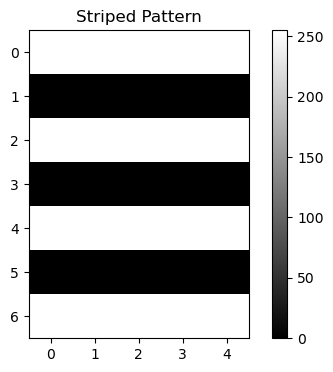

In [22]:
# Create a striped pattern
M_stripes = np.zeros((7, 5), dtype=np.uint8)
M_stripes[::2, :] = 255  # Every other row

print('Striped pattern:')
print(M_stripes)

# Visualize it
plt.imshow(M_stripes, cmap='gray')
plt.title('Striped Pattern')
plt.colorbar()
plt.show()

---
## 4. Plotting with Matplotlib <a id='plotting'></a>

Visualization is crucial in computer vision. Let's learn the basics of Matplotlib.

### 4.1 Simple Line Plots

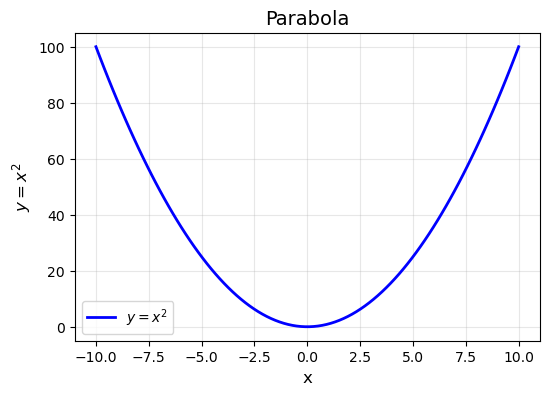

In [23]:
# Generate data
x = np.linspace(-10, 10, 100)  # 100 points from -10 to 10
y = x ** 2

# Create plot
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'b-', linewidth=2, label=r'$y = x^2$')
plt.xlabel('x', fontsize=12)
plt.ylabel(r'$y = x^2$', fontsize=12)
plt.title('Parabola', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

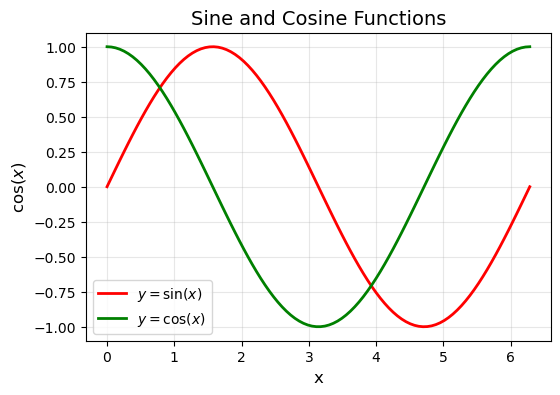

In [24]:
# Sine wave
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)
z = np.cos(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, 'r-', linewidth=2, label=r'$y = \sin(x)$')
plt.plot(x, z, 'g-', linewidth=2, label=r'$y = \cos(x)$')
plt.xlabel('x', fontsize=12)
plt.ylabel(r'$\sin(x)$', fontsize=12)
plt.ylabel('$\cos(x)$', fontsize=12,)  # Add label for cosine
plt.title('Sine and Cosine Functions', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 4.2 3D Surface Plots

We can visualize 2D functions using 3D surface plots.

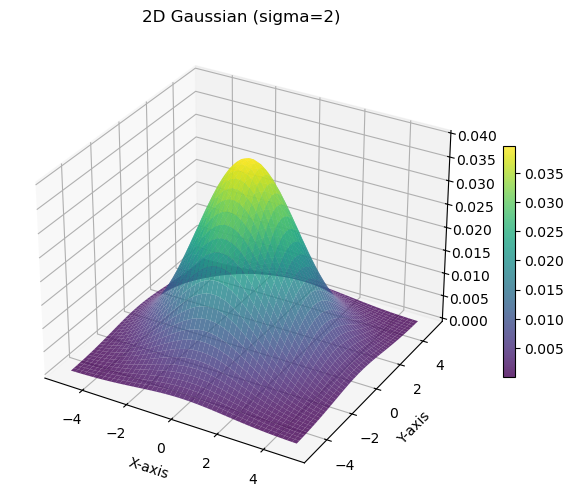

Shape of G: (50, 50)
Sum of all values: 23.4986


In [25]:
# Create a 2D Gaussian function
def gaussian_2d(x, y, sigma=1):
    """2D Gaussian function"""
    return (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))

# Create grid
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)

# Calculate Gaussian values
sigma = 2
G = gaussian_2d(X, Y, sigma)

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, G, cmap='viridis', alpha=0.8)

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title(f'2D Gaussian (sigma={sigma})')
fig.colorbar(surf, shrink=0.5)
plt.show()

print(f'Shape of G: {G.shape}')
print(f'Sum of all values: {G.sum():.4f}')

---
## 5. Image Processing Basics <a id='images'></a>

Now let's work with real images using OpenCV.

### 5.1 Reading and Displaying Images

‼️ <span style="color:red"> OpenCV uses BGR color format by default, while Matplotlib uses RGB. </span>

Grayscale image shape: (750, 1000)
Data type: uint8
Pixel value at (100, 100): 136
Min pixel value: 0
Max pixel value: 255


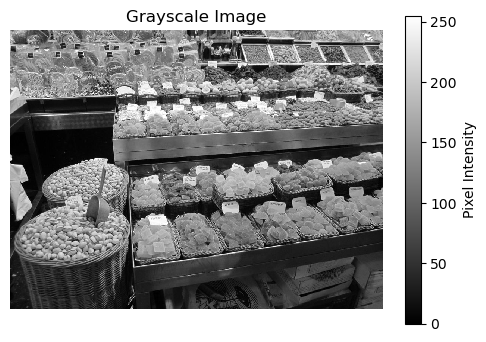

In [26]:
# Read image as grayscale
im_gray = cv2.imread('yami.jpg', cv2.IMREAD_GRAYSCALE)

if im_gray is None:
    print("Error: Could not read image. Make sure 'yami.jpg' is in the current directory.")
else:
    print(f'Grayscale image shape: {im_gray.shape}')
    print(f'Data type: {im_gray.dtype}')
    print(f'Pixel value at (100, 100): {im_gray[100, 100]}')
    print(f'Min pixel value: {im_gray.min()}')
    print(f'Max pixel value: {im_gray.max()}')
    
    # Display image
    plt.figure(figsize=(6, 4))
    plt.imshow(im_gray, cmap='gray')
    plt.title('Grayscale Image')
    plt.colorbar(label='Pixel Intensity')
    plt.axis('off')
    plt.show()

Color image shape: (750, 1000, 3)
RGB values at (100, 100): [212 105  97]


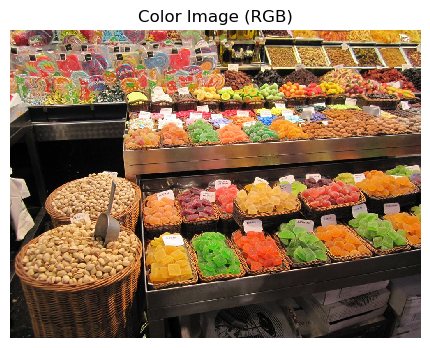

In [27]:
# Read color image
im_bgr = cv2.imread('yami.jpg', cv2.IMREAD_COLOR)

if im_bgr is not None:
    # Convert BGR to RGB for proper display in matplotlib
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
    
    print(f'Color image shape: {im_rgb.shape}')  # (height, width, channels)
    print(f'RGB values at (100, 100): {im_rgb[100, 100]}')
    
    # Display color image
    plt.figure(figsize=(6, 4))
    plt.imshow(im_rgb)
    plt.title('Color Image (RGB)')
    plt.axis('off')
    plt.show()

### 5.2 Basic Image Operations

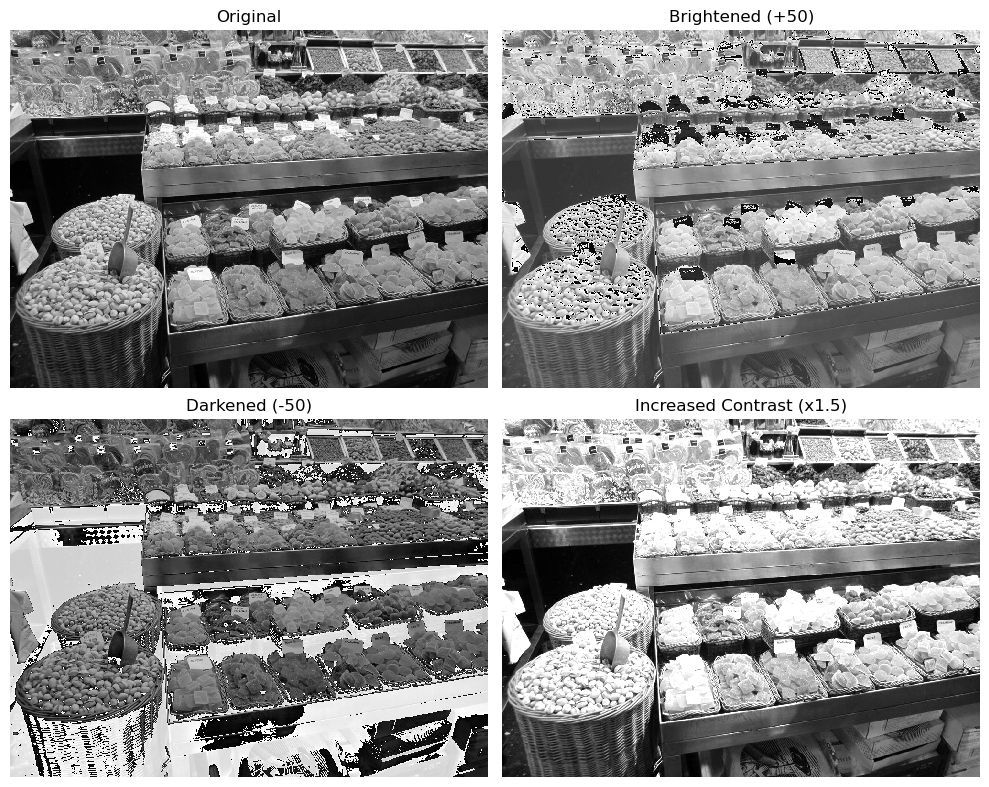

In [28]:
if im_gray is not None:
    # Brighten image (add constant)
    im_bright = np.clip(im_gray + 50, 0, 255).astype(np.uint8)
    
    # Darken image (subtract constant)
    im_dark = np.clip(im_gray - 50, 0, 255).astype(np.uint8)
    
    # Increase contrast (multiply)
    im_contrast = np.clip(im_gray * 1.5, 0, 255).astype(np.uint8)
    
    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    axes[0, 0].imshow(im_gray, cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(im_bright, cmap='gray')
    axes[0, 1].set_title('Brightened (+50)')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(im_dark, cmap='gray')
    axes[1, 0].set_title('Darkened (-50)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(im_contrast, cmap='gray')
    axes[1, 1].set_title('Increased Contrast (x1.5)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

### Something Feels Off?

After subtracting 50 from the image, the result may not look darker as expected. Some pixels may appear unexpectedly bright.

This typically happens because the image is stored as **`uint8`**.

`uint8` values are limited to the range **0–255**. When subtraction produces a negative value, it **wraps around** instead of becoming negative.

Example:

```
10 - 50 = -40  (expected)
uint8 result → 216
```

So pixels that should become dark may instead become **very bright**.

### Fix

Convert the image to a larger signed type before performing arithmetic:

```python
 np.clip(im_gray.astype(np.int16) - 50, 0, 255).astype(np.uint8)
```

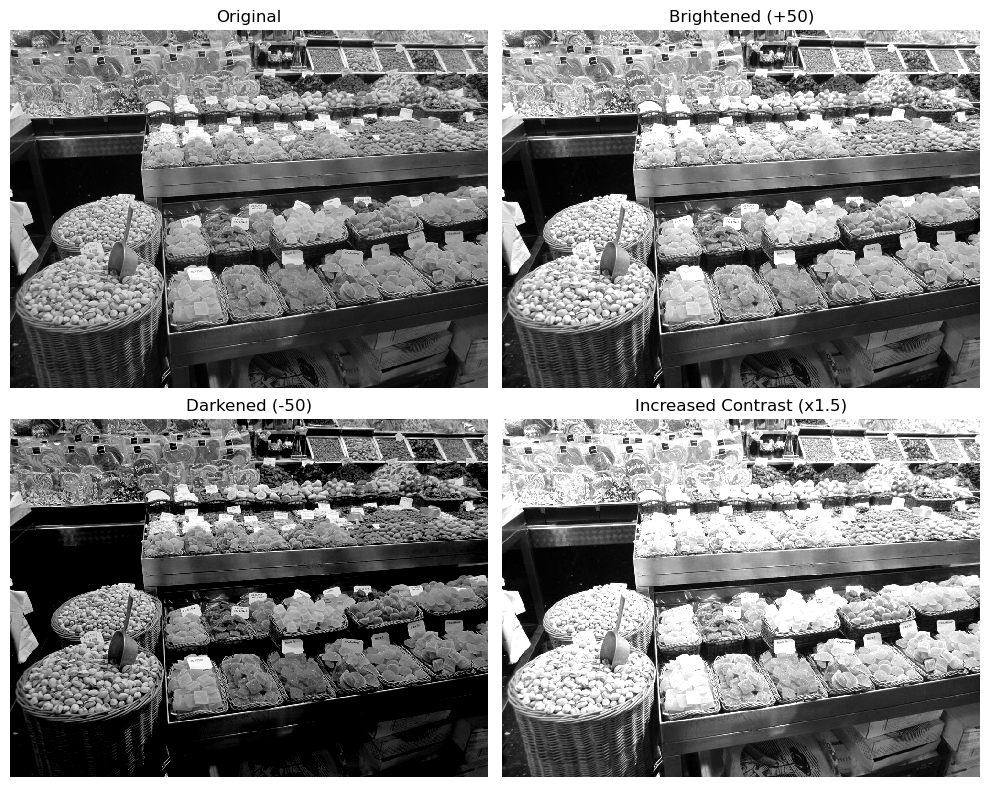

In [29]:
if im_gray is not None:
    # Brighten image (add constant)
    im_bright = np.clip(im_gray.astype(np.int16) + 50, 0, 255).astype(np.uint8)
    
    # Darken image (subtract constant)
    im_dark = np.clip(im_gray.astype(np.int16) - 50, 0, 255).astype(np.uint8)
    
    # Increase contrast (multiply)
    im_contrast = np.clip(im_gray.astype(np.int16) * 1.5, 0, 255).astype(np.uint8)
    
    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    axes[0, 0].imshow(im_gray, cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(im_bright, cmap='gray')
    axes[0, 1].set_title('Brightened (+50)')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(im_dark, cmap='gray')
    axes[1, 0].set_title('Darkened (-50)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(im_contrast, cmap='gray')
    axes[1, 1].set_title('Increased Contrast (x1.5)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

### 5.3 Image Thresholding

Thresholding converts a grayscale image to binary (black and white).

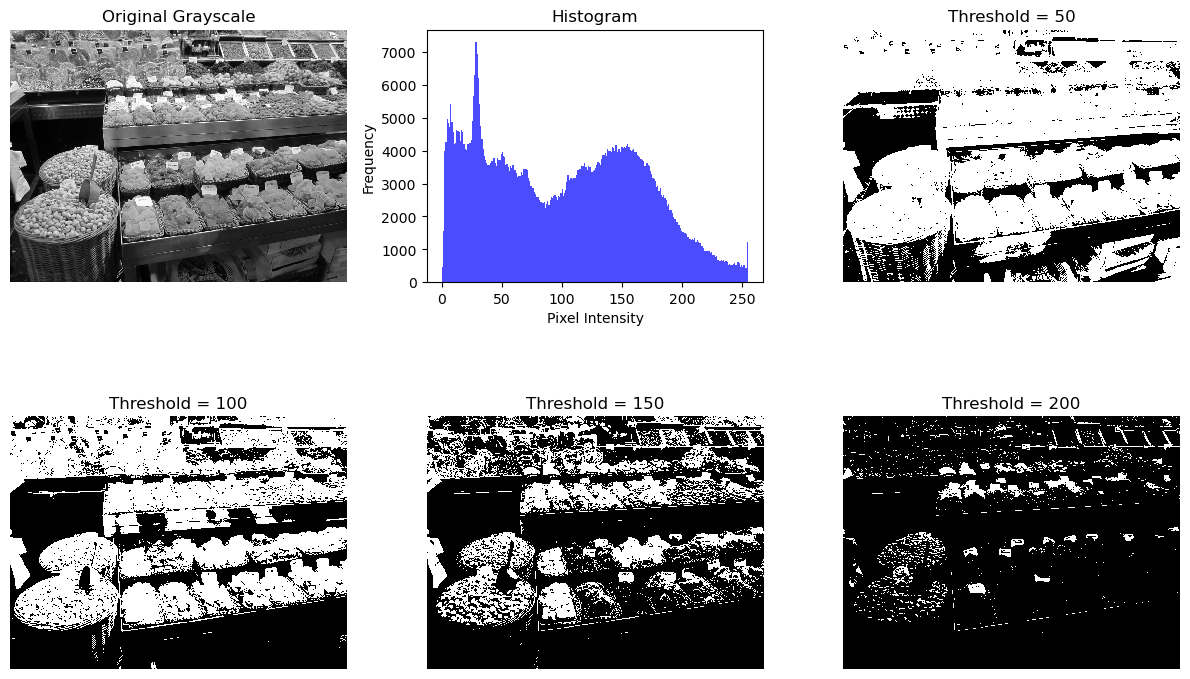

In [30]:
if im_gray is not None:
    # Apply different thresholds
    thresh_values = [50, 100, 150, 200]
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    
    # Original image
    axes[0].imshow(im_gray, cmap='gray')
    axes[0].set_title('Original Grayscale')
    axes[0].axis('off')
    
    # Histogram
    axes[1].hist(im_gray.ravel(), bins=256, color='blue', alpha=0.7)
    axes[1].set_title('Histogram')
    axes[1].set_xlabel('Pixel Intensity')
    axes[1].set_ylabel('Frequency')
    axes[1].set_box_aspect(0.75)
    
    # Thresholded images
    for i, thresh in enumerate(thresh_values):
        _, im_thresh = cv2.threshold(im_gray, thresh, 255, cv2.THRESH_BINARY)
        axes[i+2].imshow(im_thresh, cmap='gray')
        axes[i+2].set_title(f'Threshold = {thresh}')
        axes[i+2].axis('off')
    
    plt.tight_layout()
    plt.show()

### 5.4 Connected Components Analysis

Connected components help identify separate objects in binary images.

Number of connected components (including background): 2291

Component statistics (Area, Left, Top, Width, Height):
Component |  Area   | Left | Top | Width | Height
--------------------------------------------------
        0 |  546368 |    0 |   0 |  1000 |    750
        1 |   49790 |    0 |   0 |  1000 |    176
        2 |       2 |   43 |   0 |     2 |      1
        3 |       5 |   50 |   0 |     3 |      2
        4 |       2 |   77 |   0 |     2 |      1
        5 |       3 |   80 |   1 |     3 |      2
        6 |      15 |  102 |   0 |     5 |      5
        7 |      48 |  115 |   0 |    10 |      8
        8 |       2 |  128 |   1 |     1 |      2
        9 |       9 |  131 |   1 |     5 |      3


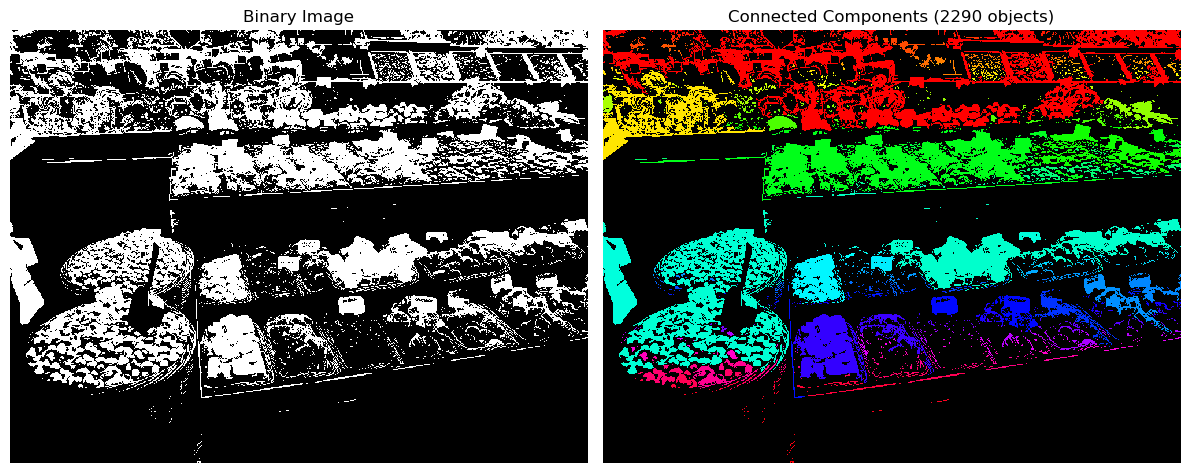

In [31]:
if im_gray is not None:
    # Threshold the image
    _, im_binary = cv2.threshold(im_gray, 150, 255, cv2.THRESH_BINARY)
    
    # Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(im_binary)
    
    print(f'Number of connected components (including background): {num_labels}')
    print(f'\nComponent statistics (Area, Left, Top, Width, Height):')
    print('Component |  Area   | Left | Top | Width | Height')
    print('-' * 50)
    for i in range(min(10, num_labels)):  # Show first 10 components
        area = stats[i, cv2.CC_STAT_AREA]
        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        print(f'{i:9d} | {area:7d} | {left:4d} | {top:3d} | {width:5d} | {height:6d}')

    # Visualize components
    # Create colored label image
    label_hue = np.uint8(179 * labels / np.max(labels))
    blank_ch = 255 * np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2RGB)
    labeled_img[labels == 0] = 0  # Set background to black
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(im_binary, cmap='gray')
    axes[0].set_title('Binary Image')
    axes[0].axis('off')
    
    axes[1].imshow(labeled_img)
    axes[1].set_title(f'Connected Components ({num_labels-1} objects)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

---
## 6. Your Exercises <a id='exercises'></a>

Now it's your turn! Complete the following exercises to practice what you've learned.

### Exercise 1: Working with the Gaussian Function

Using the Gaussian function `G` created above, complete the following tasks:

1. **Print the shape of G**
2. **Normalize G** so that the sum of all elements equals 1
3. **Plot a 1D slice** of the Gaussian along the x-axis where y=0

In [32]:
# Create grid
x = np.linspace(-5, 5, 51)
y = np.linspace(-5, 5, 51)
X, Y = np.meshgrid(x, y)

# Calculate Gaussian values
sigma = 2
G = gaussian_2d(X, Y, sigma)

In [33]:
# Task 1: Print the shape of G
# YOUR CODE HERE
print(f'Shape of G: ')
G.shape

Shape of G: 


(51, 51)

In [34]:
# Task 2: Normalize G so sum equals 1
# YOUR CODE HERE
# Hint: Divide G by its sum
G_normalized = G / G.sum()  # Replace with your code

# Verify normalization
if G_normalized is not None:
    print(f'Sum of normalized G: {G_normalized.sum():.6f}')
    print('Correct!' if abs(G_normalized.sum() - 1.0) < 0.0001 else 'Try again')

Sum of normalized G: 1.000000
Correct!


C:\Users\Mendel\AppData\Local\Temp\ipykernel_31048\534181997.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


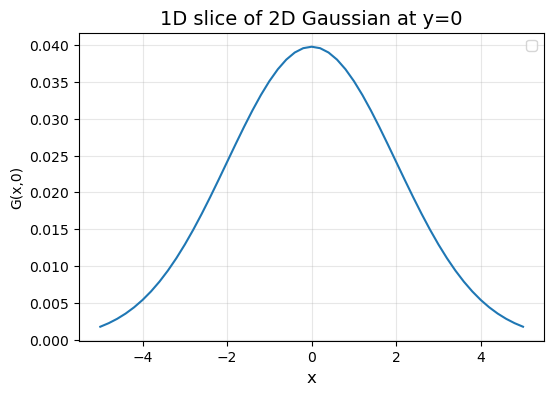

In [35]:
# Task 3: Plot 1D slice of Gaussian where y=0
# YOUR CODE HERE
# Hint: Find the middle row of G (where y=0)

plt.figure(figsize=(6, 4))
plt.plot(x,G[len(y)//2,:])
plt.xlabel('x', fontsize=12)
plt.ylabel("G(x,0)")
plt.title('1D slice of 2D Gaussian at y=0', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Exercise 2: Image Processing Pipeline

Create a complete image processing pipeline:

1. **Load your own image** (or use one of the provided images)
2. **Convert to grayscale** if it's a color image
3. **Apply thresholding** with a threshold value of your choice
4. **Find connected components** in the thresholded image
5. **Identify the largest component** (excluding background)
6. **Create a mask** showing only the largest component
7. **Display results** side-by-side

In [36]:
# Task 1: Load your image
# YOUR CODE HERE
# You can use 'yami.jpg' or your own image
my_image = cv2.imread('yami.jpg')  # Replace with a call to cv2.imread

if my_image is not None:
    print(f'Image loaded successfully! Shape: {my_image.shape}')
else:
    print('Please load an image first!')

Image loaded successfully! Shape: (750, 1000, 3)


Grayscale image shape: (750, 1000)


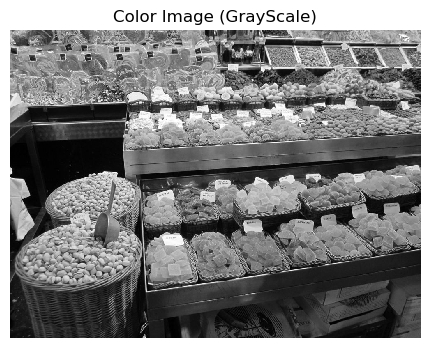

In [37]:
# Task 2: Convert to grayscale
# YOUR CODE HERE
# Hint: Check if image has 3 channels, then use cv2.cvtColor
if my_image is not None:
    if my_image.ndim == 3:
        my_gray = cv2.cvtColor(my_image,cv2.COLOR_BGR2GRAY)  # Replace with a call to cv2.cvtColor
    else:
        my_gray = my_image
    
    if my_gray is not None:
        print(f'Grayscale image shape: {my_gray.shape}')
        plt.figure(figsize=(6, 4))
        plt.imshow(my_gray)
        plt.title('Color Image (GrayScale)')
        plt.axis('off')
        plt.show()

Binary image created with threshold = 120
Number of white pixels: 317313
Number of black pixels: 432687


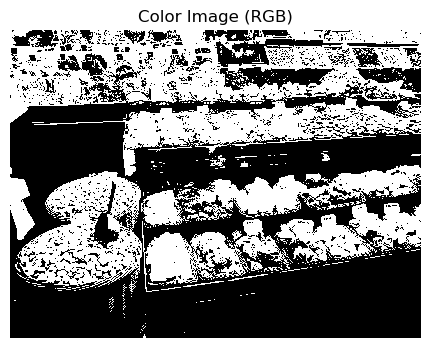

In [47]:
# Task 3: Apply thresholding
# YOUR CODE HERE
# Choose a threshold value (try values between 50-150)
threshold_value = 120  # Adjust this value

if my_gray is not None:
    # Apply threshold
    _, my_binary = cv2.threshold(my_gray,threshold_value,255,cv2.THRESH_BINARY) # Replace with a call to cv2.threshold
    
    if my_binary is not None:
        print(f'Binary image created with threshold = {threshold_value}')
        print(f'Number of white pixels: {np.sum(my_binary == 255)}')
        print(f'Number of black pixels: {np.sum(my_binary == 0)}')
        plt.figure(figsize=(6, 4))
        plt.imshow(my_binary)
        plt.title('Color Image (RGB)')
        plt.axis('off')
        plt.show()

In [ ]:
# Task 4: Find connected components
if my_binary is not None:
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(my_binary)     
    #To use the function above we need to pass a binary image as my_binary which is why we usually use cv2.treshold before and pass the result to this function.
    if num_labels is not None:
        print(f'Number of labels found: {num_labels}')

Number of components found: 1018


In [49]:
# Task 5: Find the largest component (excluding background)
# YOUR CODE HERE
# Hint: Background is usually component 0
# Find the component with maximum area (excluding index 0)
if num_labels is not None and num_labels > 1:
    # Get areas of all components except background (index 0)
    areas = stats[1:, cv2.CC_STAT_AREA]
    
    largest_component_idx = 1
    largest_area = areas[0] 

    for i in range(2,len(areas)):
        if areas[i]>largest_area:
            largest_component_idx = i
            largest_area = areas[i]
    
    print(f'Largest component index: {largest_component_idx}')
    print(f'Largest component area: {largest_area} pixels')

Largest component index: 1
Largest component area: 110329 pixels


In [ ]:
# Task 6: Create mask for largest component
# YOUR CODE HERE
if largest_component_idx is not None:
    # Create a binary mask where only the largest component is white
    largest_mask = None  # Replace with your code
    
    if largest_mask is not None:
        print(f'Mask created! Shape: {largest_mask.shape}')
        print(f'Number of pixels in largest component: {np.sum(largest_mask == 255)}')

In [ ]:
# Task 7: Display all results
# YOUR CODE HERE
if my_gray is not None and my_binary is not None and largest_mask is not None:
    # Create a colored overlay showing the largest component
    overlay = cv2.cvtColor(my_gray, cv2.COLOR_GRAY2RGB)
    overlay[largest_mask == 255] = [255, 0, 0]  # Highlight in red
    
    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(my_gray, cmap='gray')
    axes[0, 0].set_title('1. Original Grayscale')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(my_binary, cmap='gray')
    axes[0, 1].set_title(f'2. Binary (threshold={threshold_value})')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(largest_mask, cmap='gray')
    axes[1, 0].set_title(f'3. Largest Component')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title('4. Overlay on Original')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print('\nExercise 2 complete!')

---
## Summary

Congratulations! You've completed the warm-up exercise. You should now be familiar with:

- Setting up your Python environment with NumPy, OpenCV, and Matplotlib  
- Creating and manipulating NumPy arrays  
- Performing mathematical operations on arrays  
- Creating visualizations with Matplotlib  
- Loading and processing images  
- Applying thresholding and finding connected components  

These skills will be essential throughout the course. If you had any difficulties, please:
- Review the example code
- Check the official documentation for [NumPy](https://numpy.org/doc/), [OpenCV](https://docs.opencv.org/), and [Matplotlib](https://matplotlib.org/)
- Ask questions on Piazza

**Next steps:** Get ready for HW1, where you'll apply these concepts to real computer vision problems!

---

*Note: This is a warm-up exercise and is not graded. However, completing it will help you succeed in the upcoming assignments.*